# 1. Basic parameters:

In [15]:
import typing
import networkx as nx
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.patches as mpatches

N_STATE = 4
N_ITER = 200
ITERS = np.arange(N_ITER)
ALPHA = 0.11

# 2. Define the graph.

We consider a network consisting of two categories of nodes with corresponding edges:

```python
NORMAL_NODES = [...]
NORMAL_EDGES = [...]

BYZANTINE_NODES = [...]
BYZANTINE_EDGES = [...]
```

The overall network is formed by the union of the normal and Byzantine nodes and edges:

$$
\mathcal{I} = \mathcal{I}_\text{normal} \cup \mathcal{I}_\text{Byz}, \quad \mathcal{E} = \mathcal{E}_\text{normal} \cup \mathcal{E}_\text{Byz}.
$$

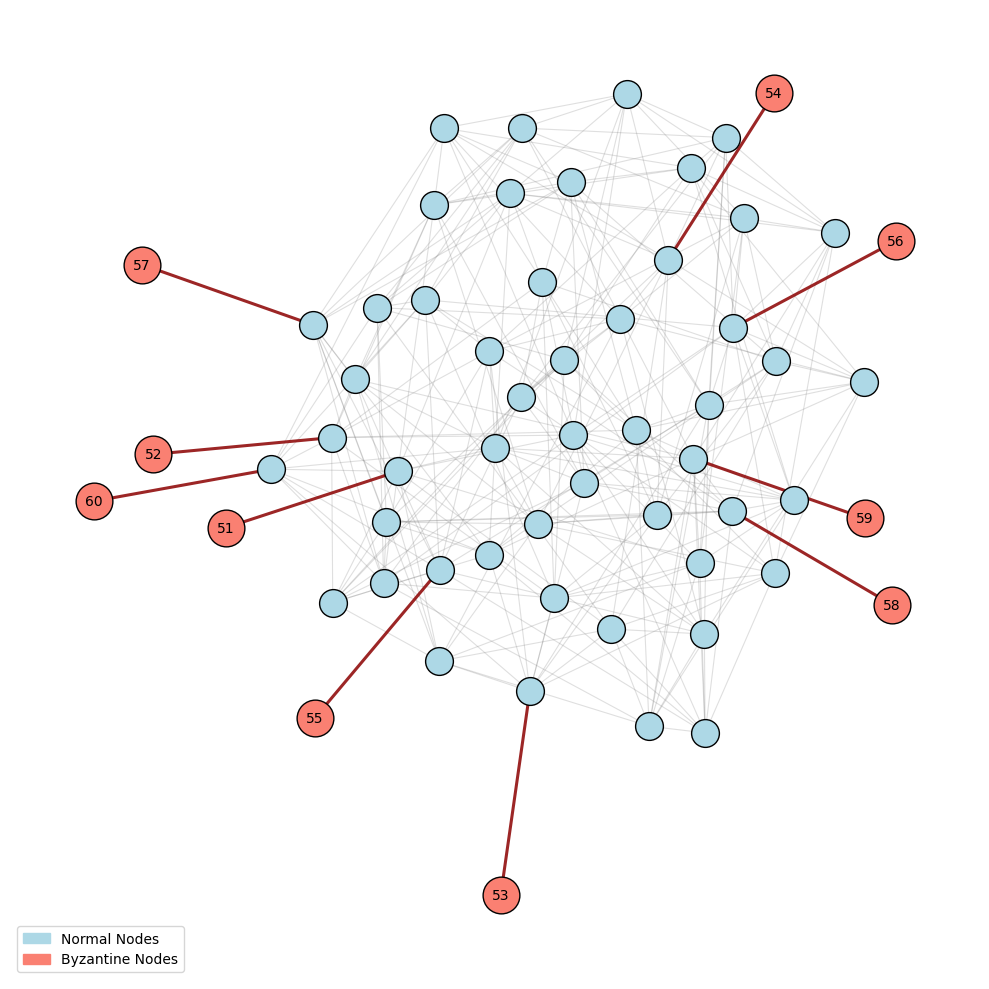

In [16]:
n = 50
d = 10

G_: nx.Graph = nx.random_regular_graph(d, n, seed=42)

mapping = {i: str(i + 1) for i in range(n)}
G_ = nx.relabel_nodes(G_, mapping)

NORMAL_NODES: list[str] = list(G_.nodes())
NORMAL_EDGES: list[tuple[str, str]] = list(G_.edges())

BYZANTINE_NODES = ["51", "52", "53", "54", "55", "56", "57", "58", "59", "60"]
BYZANTINE_EDGES = [
    ("1", "51"),
    ("2", "52"),
    ("3", "53"),
    ("4", "54"),
    ("5", "55"),
    ("6", "56"),
    ("7", "57"),
    ("8", "58"),
    ("9", "59"),
    ("10", "60"),
]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

plt.rcdefaults()

fig, ax = plt.subplots(figsize=(10, 10))

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

G_normal = G.subgraph(NORMAL_NODES)
pos_normal = nx.spring_layout(G_normal, seed=15, k=0.5)

pos: dict[str, npt.NDArray[np.float64]] = dict(pos_normal)

# Place each Byzantine node slightly outside the normal node it is connected to.
PUSH = 0.6

for u, v in BYZANTINE_EDGES:
    p = pos[u]
    r = np.linalg.norm(p)
    if r < 1e-9:
        direction = np.array([1.0, 0.0])
    else:
        direction = p / r

    cand = p + PUSH * direction

    pos[v] = cand

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=NORMAL_EDGES,
    width=0.8,
    alpha=0.25,
    edge_color="gray",
    ax=ax,
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=BYZANTINE_EDGES,
    width=2.2,
    edge_color="#8B0000",
    alpha=0.85,
    style="solid",
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=400,
    edgecolors="black",
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=700,
    edgecolors="black",
    ax=ax,
)

nx.draw_networkx_labels(
    G,
    pos,
    labels={node: node for node in BYZANTINE_NODES},
    font_size=10,
    ax=ax,
)

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")

ax.axis("off")
plt.tight_layout()

# 3. Set up the cluster and run the algorithms

---

## Byzantine nodes

A Byzantine node ignores the states of its neighbors.
Let the state of node $i$ at iteration $t$ be denoted as $x_i^{(t)}$.
Then the update rule for a Byzantine node can be described as:

1. **Keep state constant:**
   $$
   x_i^{(t+1)} = x_i^{(t)}
   $$

2. **Update state randomly:**
   $$
   x_i^{(t)} \sim \mathcal{U}(a, b)
   $$
   where $\mathcal{U}(a, b)$ denotes a uniform random variable in the range $[a, b]$, which represents the possible values that the Byzantine node can take.

3. **Add perturbation:**
   $$
   x_i^{(t+1)} = x_i^{(t)} - \alpha \sum_{j \in \mathcal{N}_i} \big(x_i^{(t)} - x_j^{(t)}\big) + \eta_i^{(t)}
   $$
   where $\eta_i^{(t)}$ is an interference term (noise) that can be modeled as either deterministic or stochastic, e.g.
   $$
   \eta_i^{(t)} \sim \mathcal{U}(a, b).
   $$
   This form represents a Byzantine node that actively injects perturbations into its state to disrupt the consensus process.

---

## Standard consensus algorithm

In our system, the state of each node is updated using a consensus iteration. Let $x_i^{(t)} \in \mathbb{R}^d$ denote the state of node $i$ at iteration $t$, where $d$ is the dimension of the state.
The consensus update is given by

$$
x_i^{(t+1)} = x_i^{(t)} - \alpha \sum_{j \in \mathcal{N}_i}(x_i^{(t)} - x_j^{(t)})
$$

where $\mathcal{N}_i$ is the set of neighbors of node $i$, and $\alpha > 0$ is the step size.

---

## Adaptive reputation-based consensus algorithm

### Loss function

#### Option I: Quasi geometric median loss

   For each node $i$ and each neighbor $j \in \mathcal{N}_i$, we define the loss as

   $$
   l_{ij}^{(t)} = \sum_{v \in \mathcal{N}_i} \frac{\| x_j^{(t)} - x_v^{(t)} \|}{d_i},
   $$

   where $x_j^{(t)}$ denotes the state received from neighbor $j$ at iteration $t$, $\mathcal{N}_i$ is the set of neighbors of node $i$, and $d_i = |\mathcal{N}_i|$ denotes its degree.

   This loss quantifies the local geometric inconsistency between neighbor $j$ and the remaining neighbors of node $i$. It can be viewed as a **quasi–geometric median** measure, since it approximates the notion of the **geometric median**, defined as

   $$
   {gm}_i = \arg\min_x \sum_{v \in \mathcal{N}_i} \|x - x_v\|.
   $$

   Neighbors closer to this geometric median yield smaller losses, while outliers or Byzantine neighbors exhibit larger ones.

#### Option II: Geometric median loss:

   Also, we define the **geometric median loss**, which directly measures the distance of each neighbor's state to the true geometric median:

   $$
   l_{ij}^{(t)} = \| x_j^{(t)} - {gm}_{i}^{(t)} \|,
   $$

   where 
   $$
   {gm}_{i}^{(t)} = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v^{(t)} \|
   $$
   is the **geometric median** of node $i$’s neighbors at iteration $t$.

   Computing the geometric median at each iteration requires solving a non-smooth convex optimization problem, which can be computationally expensive compared to the quasi geometric median or coordinate-wise median.

#### Option III: Coordinate-wise median loss:

   Alternatively, we define a **coordinate-wise median loss**, which quantifies the deviation of each neighbor's state from the coordinate-wise median of all neighbors:

   $$
   l_{ij}^{(t)} = \| x_j^{(t)} - {cm}_{i}^{(t)} \|_1,
   $$

   where 
   $$
   {cm}_{i}^{(t)} = \arg\min_x \sum_{v \in \mathcal{N}_i} \| x - x_v^{(t)} \|_1
   $$
   denotes the coordinate-wise median of node $i$’s neighbors at iteration $t$.

   Note that since the coordinate-wise median is computed independently across coordinates, ${cm}_i^{(t)}$ is **not necessarily a convex combination of the neighbors and may even lie outside their convex hull**.

#### Option IIII: Mean loss:

   We define the **mean loss**, which measures each neighbor’s deviation from the average of all neighbor states:

   $$
   l_{ij}^{(t)} = \| x_j^{(t)} - m_i^{(t)} \|
   $$

   where
   $$
   m_{i}^{(t)} = \frac{1}{d_i} \sum_{v \in \mathcal{N}_i} x_v^{(t)}
   $$

   denotes the mean state of node $i$'s neighbors at iteration $t$.

   Although the mean is theoretically non-robust and highly sensitive to outliers or Byzantine neighbors, its empirical performance in our setting turns out to be **surprisingly strong**.

#### Option V: Trimmed-mean loss:

   We define the **trimmed-mean loss**, which mitigates the influence of extreme neighbor values by averaging only the central subset of neighbor states:

   $$
   l_{ij}^{(t)} = \| x_j^{(t)} - tm_i^{(t)} \|
   $$

   Here $tm_i^{(t)}$ denotes the **coordinate-wise trimmed mean**. For each coordinate $k$, we remove the largest $f$ and smallest $f$ neighbor values and average the remaining ones:

   $$
   tm_{i,k}^{(t)} = \frac{1}{d_i - 2f} \sum_{v \in S_{i,k}^{(t)}} x_{v,k}^{(t)}
   $$

   where $S_{i,k}^{(t)}$ is the set of neighbors whose $k$-th coordinate lies in the central $d_i - 2f$ range after discarding the $f$ largest and $f$ smallest values.

   > **Practical consideration:** This loss requires an additional hyperparameter $f$, which implicitly assumes prior knowledge of the number of extreme or faulty neighbors. Such information is typically unavailable in practice, making the choice of $f$ unrealistic. Therefore, the trimmed-mean loss is included for conceptual completeness but is **not used in practice**.

### Cumulative loss

Using **instantaneous loss only** for weight assignment is insufficient in Byzantine-resilient settings, as it fails to capture the long-term impact of **persistent but small-magnitude adversarial perturbations**.
A Byzantine node may inject carefully crafted deviations that remain below detection thresholds at each iteration, yet gradually cumulate and lead to a significant bias in the aggregated estimate. Relying solely on instantaneous loss would therefore render the system blind to such slow but systematic attacks.

Conversely, **retaining full historical memory** is also undesirable in adversarial and nonstationary environments.
A malicious node may behave honestly for an extended period to cumulate trust and then exploit this long-term memory to exert disproportionate influence during an attack phase.
Moreover, even when all neighbors are honest and eventually reach consensus, their cumulative losses are typically different due to early-stage discrepancies and local noise, which violates the goal of **treating all honest nodes equally**.

These observations indicate that an effective defense against Byzantine behavior requires a **finite-memory loss mechanism** that can cumulate evidence over time while gradually forgetting outdated information.

#### Option I: Exponentially decayed

A first approach is to adopt a **decayed cumulative loss** with a forgetting factor $\lambda \in (0,1]$:
$$
L_{ij}^{(t)} = \lambda\, L_{ij}(t - 1) + l_{ij}^{(t)}.
$$

This formulation emphasizes recent observations while gradually discounting older information. By tuning $\lambda$, the effective memory length can be adjusted, interpolating between the instantaneous-loss regime ($\lambda = 0$) and long-term averaging.

#### Option II: Moving-horizon

An alternative approach is to impose an explicit **moving horizon** of length $H$, which restricts the loss to the most recent $H$ observations and **discards all earlier history**. The moving-horizon (windowed) cumulative loss is defined as
$$
L_{ij}^{(t)} = \sum_{\tau=\max(0,t-H+1)}^{t} l_{ij}(\tau).
$$

For online implementation, $L_{ij}^{(t)}$ admits the recursion
$$
L_{ij}^{(t)} = L_{ij}^{(t-1)} + l_{ij}^{(t)} - l_{ij}^{(t-H)},
$$
where $l_{ij}^{(s)}=0$ for $s < 0$.

This moving-horizon formulation provides a strict finite-memory mechanism: it cumulates evidence over the last $H$ rounds to detect persistent small attacks, while ensuring that any behavior prior to the window has no influence on the current weights.

### Probabilistic selection via loss normalization

In multi-class classification and attention mechanisms, **normalization mappings** are used to transform a vector of real-valued scores into a probability distribution over classes or tokens. Softmax is the most widely used mapping, while Sparsemax and Entmax have been proposed to address its limitations in terms of sparsity and interpretability.

#### Option I: Softmax

**Softmax** maps an input vector to a strictly positive probability distribution by exponentiation and normalization:

$$
\operatorname{softmax}(z_i) = \frac{\exp(z_i)}{\sum_j \exp(z_j)}
$$

**Properties:**
- Produces a **dense probability distribution** (all entries are strictly positive)
- Smooth and fully differentiable, making it well-suited for gradient-based optimization

**Limitations:**
- Cannot produce exact zeros
- Often yields diffuse attention distributions, reducing interpretability

#### Option II: Sparsemax

**Sparsemax** is defined as the Euclidean projection of the input vector onto the probability simplex:

$$
\operatorname{sparsemax}(z) = \arg\min_{p \in \Delta} \|p - z\|^2
$$

where the probability simplex is defined as:

$$
\Delta = \left\{ p \in \mathbb{R}^K \mid p \ge 0,\ \sum_i p_i = 1 \right\}
$$

**Properties:**
- Produces **sparse probability distributions**, with some components exactly equal to zero
- Improves interpretability, especially in attention-based models
- Less sensitive to small score variations than Softmax

**Drawbacks:**
- Gradients may be discontinuous at the boundary of the simplex

#### Option III: Entmax

**Entmax** generalizes Softmax and Sparsemax by introducing a parameterized entropy based on Tsallis entropy, controlled by $\alpha$:

$$
\operatorname{\alpha-entmax}(z) = \arg\max_{p \in \Delta} \left( p^\top z + H_\alpha(p) \right)
$$

where the Tsallis $\alpha$-entropy is defined as:

$$
H_\alpha(p) =
\begin{cases}
\displaystyle \frac{1}{\alpha(\alpha - 1)} \left( 1 - \sum_i p_i^\alpha \right), & \alpha \neq 1 \\\\
\displaystyle -\sum_i p_i \log p_i, & \alpha = 1
\end{cases}
$$

Special cases:
- $\alpha = 1$: equivalent to Softmax  
- $\alpha = 1.5$: a commonly used setting with a **closed-form solution**, offering a practical balance between smoothness and sparsity  
- $\alpha = 2$: equivalent to Sparsemax  

**Properties:**
- Allows **continuous control of sparsity** via the parameter $\alpha$
- Provides a flexible trade-off between smoothness and sparsity

### Comparison Summary

<div align="center">

| Method    | Sparse Output | Tunable Sparsity | Interpretability |
|-----------|---------------|------------------|------------------|
| Softmax   | No            | No               | Low              |
| Sparsemax | Yes           | No               | High             |
| Entmax    | Yes           | Yes              | High             |

</div>

In summary, Softmax prioritizes smoothness and numerical stability, Sparsemax emphasizes sparsity and interpretability, and Entmax provides a unified framework that interpolates between the two.

### The proposed algorithm

#### Initialization

For each node $i$:

- Initialize the local state randomly:  
  $$
  x_i^{(0)} \sim \text{Random}.
  $$  

- Initialize the cumulative loss:  
  $$
  L_{ij}^{(0)} = 0, \quad \forall j \in \mathcal{N}_i.
  $$  


#### Iterative Update (for each time step $t = 0,1,2,\dots$)

For each node $i$, repeat:

1. Exchange the current state $x_i^{(t)}$ with neighbors and receive  
   $$
   x_j^{(t)}, \quad \forall j \in \mathcal{N}_i.
   $$  

2. Evaluate neighbors via biased estimate

   Observe a biased estimate of the honest neighbors’ average (e.g., via the geometric median, coordinate-wise median, or trimmed mean)
   $$
   y_i^{(t)} = \mathcal{B}_i\big(\{x_j^{(t)}\}_{j \in \mathcal{N}_i}\big),
   $$
   and then evaluate the corresponding losses
   $$
   l_{ij}^{(t)} = \ell\big(x_j^{(t)}, y_i^{(t)}\big), \quad \forall j \in \mathcal{N}_i
   $$

3. Update the cumulative loss

   - **Exponentially decayed**:
     $$
     L_{ij}^{(t)} = \lambda\,L_{ij}^{(t-1)} + l_{ij}^{(t)}, \qquad j\in\mathcal{N_i}.
     $$

   - **Moving-horizon**:
     $$
     L_{ij}^{(t)} = L_{ij}^{(t-1)} + l_{ij}^{(t)} - l_{ij}^{(t-H)}, \qquad j\in\mathcal{N_i},
     $$
     where $l_{ij}^{(s)}=0$ for $s < 0$.

3. Normalize the cumulative loss to the probability simplex

   Define the vectors
   $$
   L_i^{(t)} = \big[L_{ij}^{(t)}\big]_{j\in\mathcal N_i}, \qquad p_i^{(t)} = \big[p_{ij}^{(t)}\big]_{j\in\mathcal N_i}.
   $$

   Compute the probability distribution by mapping the cumulative losses onto the probability simplex:
   - **Smooth, strictly positive**:
     $$
     p_i^{(t+1)} = \operatorname{softmax}\!\big(-\eta L_i^{(t+1)}\big).
     $$

   - **Sparsity-inducing**:
     $$
     p_i^{(t+1)} = \operatorname{sparsemax}\!\big(-\eta L_i^{(t+1)}\big).
     $$

   - **Intermediate sparsity**:
     $$
     p_i^{(t+1)} = \operatorname{1.5-entmax}\!\big(-\eta L_i^{(t+1)}\big).
     $$

   Here $\eta$ controls the sensitivity of the probability assignment to the cumulative losses.

4. Compute the aggregated prediction and update the local state  
   $$
   x_i^{(t+1)} = (1 - \alpha) x_i^{(t)} + \alpha \sum_{j \in \mathcal{N}_i} p_{ij}^{(t+1)}\, x_j^{(t)},
   $$
   where $\alpha \in (0,1)$ balances the historical state and the aggregated estimate.

---

## Reputation-based consensus

1. Exchange the current state $x_i^{(t)}$ with neighbors and receive  
   $$
   x_j^{(t)}, \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute reputation

   Each node $i$ first estimates the preliminary reputation of its neighbor $j \in \mathcal{N}_i$ based on their state difference:
   $$
   \tilde{c}_{ij}^{(t)} =
   \begin{cases}
   1 - \sum_{v \in \mathcal{N}_i} \frac{\| x_j^{(t)} - x_v^{(t)} \|}{| \mathcal{N}_i |}, & j \in \mathcal{N}_i, \\[6pt]
   0, & \text{otherwise.}
   \end{cases}
   $$
   This formulation penalizes neighbors whose states significantly deviate from others in $\mathcal{N}_i$, thereby reducing their reputational weight.

3. Normalize reputation

   To ensure comparability across different neighbors, the reputations are normalized within the neighborhood:
   $$
   \tilde{\tilde{c}}_{ij}^{(t)} =
   \begin{cases}
   \dfrac{\tilde{c}_{ij}^{(t)} - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}^{(t)}}
   {\max\nolimits_{v \in \mathcal{N}_i} \tilde{c}_{iv}^{(t)} - \min\nolimits_{v \in \mathcal{N}_i}^f \tilde{c}_{iv}^{(t)}},
   & \text{if not all } \tilde{c}_{iv}^{(t)} \text{ are equal}, \\[10pt]
   1, & \text{otherwise.}
   \end{cases}
   $$

4. Trim reputation with confidence $\epsilon$

   To prevent reputations from vanishing and to maintain minimal trust even for low-confidence neighbors, a confidence-based lower bound is applied:
   $$
   c_{ij}^{(t)} =
   \begin{cases}
   \tilde{\tilde{c}}_{ij}^{(t)}, & \text{if} \quad \tilde{\tilde{c}}_{ij}^{(t)} > 0, \\[6pt]
   \epsilon^k, & \text{otherwise.}
   \end{cases}
   $$

   Here, $\min^f$ denotes a generalized order statistic defined as follows: it is obtained by first removing duplicates from the multiset $\{\tilde{c}_{iv}^{(t)} : v \in \mathcal{N}_i\}$ and then selecting the $f$-th smallest distinct value.
   If this value happens to coincide with the maximum element of the multiset,  the $(f-1)$-th smallest distinct value is used instead.

5. Aggregate states

   Finally, each node updates its state by aggregating information from its neighbors, weighted by the trimmed reputations:
   $$
   x_i^{(t+1)} = x_i^{(t)} - \alpha \frac{\sum_{j \in \mathcal{N}_i} c_{ij}^{(t)} \big( x_i^{(t)} - x_j^{(t)} \big)}{\sum_{j \in \mathcal{N}_i} c_{ij}^{(t)}}.
   $$
   This adaptive aggregation allows nodes to gradually adjust their states toward more reputable neighbors while mitigating the influence of unreliable ones.

---

## W-MSR algorithm

1. Exchange the current state

   Each node $i$ broadcasts its current state and receives the states of its neighbors:
   $$
   x_j^{(t)}, \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute neighbor trimmed mean (W-MSR)

   Given a resilience parameter $f \in \mathbb{Z}_{\ge 0}$, node $i$ sorts the received neighbor states
   $\{x_j^{(t)} : j \in \mathcal{N}_i\}$ and removes
   - up to $f$ largest values, and
   - up to $f$ smallest values.

   Let $\mathcal{N}_i^{(t)} \subseteq \mathcal{N}_i$ denote the remaining neighbor index set after trimming, and define the trimmed mean
   $$
   \bar{x}_{i,\mathrm{trim}}^{(t)} = \frac{1}{|\mathcal{N}_i^{(t)}|} \sum_{j \in \mathcal{N}_i^{(t)}} x_j^{(t)}.
   $$

3. Update local state

   Node $i$ updates its state by mixing its local value and the neighbor trimmed mean:
   $$
   x_i^{(t+1)} = (1-\alpha)\,x_i^{(t)} + \alpha\,\bar{x}_{i,\mathrm{trim}}^{(t)},
   $$
   where $\alpha \in (0,1]$.

---

## Improved ADRC algorithm

1. Exchange the current state

   Each node $i$ broadcasts its current state and receives the states of its neighbors:
   $$
   x_j^{(t)}, \quad \forall j \in \mathcal{N}_i.
   $$

2. Compute neighbor $F_i$-safe point
   $$
   s_i^{(t)} = \operatorname{IteratedRadon}(\big\{x_{j}^{(t)}\big\}_{j\in\mathcal N_i}) \quad \text{or} \quad s_i^{(t)} = \operatorname{IteratedTverberg}(\big\{x_{j}^{(t)}\big\}_{j\in\mathcal N_i})
   $$

3. Update local state

   Node $i$ updates its state by mixing its local value and the neighbor trimmed mean:
   $$
   x_i^{(t+1)} = (1-\alpha) x_i^{(t)} + \alpha s_{i}^{(t)},
   $$
   where $\alpha \in (0,1]$.

---

## WLA algorithm

For each node $i$, repeat:

1. Exchange the current state $x_i^{(t)}$ with neighbors and receive  
   $$
   x_j^{(t)}, \quad \forall j \in \mathcal{N}_i.
   $$  

2. Evaluate neighbors via biased estimate

   Evaluate the corresponding losses
   $$
   l_{ij}^{(t)} = \| x_j^{(t)} - x_i^{(t)} \|
   $$

3. Update the cumulative loss

   $$
   L_{ij}^{(t)} = L_{ij}^{(t-1)} + l_{ij}^{(t)}, \qquad j\in\mathcal{N_i}.
   $$

3. Normalize the cumulative loss to the probability simplex

   Define the vectors
   $$
   L_i^{(t)} = \big[L_{ij}^{(t)}\big]_{j\in\mathcal N_i}, \qquad p_i^{(t)} = \big[p_{ij}^{(t)}\big]_{j\in\mathcal N_i}.
   $$

   Compute the probability distribution by mapping the cumulative losses onto the probability simplex:
   $$
   p_i^{(t+1)} = \operatorname{softmax}\!\big(-\eta L_i^{(t+1)}\big).
   $$

4. Compute the aggregated prediction and update the local state  
   $$
   x_i^{(t+1)} = (1 - \alpha) x_i^{(t)} + \alpha \sum_{j \in \mathcal{N}_i} p_{ij}^{(t+1)}\, x_j^{(t)},
   $$
   where $\alpha \in (0,1)$ balances the historical state and the aggregated estimate.

---

In [ ]:
import ray

ray.init(address="local", num_cpus=N_NODES)


@ray.remote
class Node:
    def __init__(self, name: str, n_state: int, alpha: float, n_iter: int):
        from conops import NodeHandle

        self.handle = NodeHandle(name, transport="ipc")
        self.n_state = n_state
        self.alpha = alpha
        self.n_iter = n_iter

        self.lower_bound = -100.0
        self.upper_bound = 100.0

    @ray.method
    def standard(self) -> npt.NDArray[np.float64]:
        from numpy import zeros
        from numpy.random import uniform, seed

        x = zeros((self.n_iter, self.n_state))
        seed(int(self.handle.idx))  # Ensure reproducibility for each node
        x[0] = uniform(self.lower_bound, self.upper_bound, self.n_state)

        for k in range(self.n_iter - 1):
            x[k + 1] = x[k] - self.handle.laplacian(x[k]) * self.alpha

        return x

    @ray.method
    def byzantine(self) -> npt.NDArray[np.float64]:
        from numpy import zeros
        from numpy.random import seed, uniform

        x = zeros((self.n_iter, self.n_state))
        seed(int(self.handle.idx))  # Ensure reproducibility for each node

        x[0] = uniform(self.lower_bound, self.upper_bound, self.n_state)

        for k in range(self.n_iter - 1):
            _ = self.handle.exchange(x[k])
            x[k + 1] = x[k]

        return x

    @ray.method
    def algorithm_with_reps(
        self, algorithm: typing.Literal["ARepC", "RepC", "WLA"]
    ) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
        if algorithm == "ARepC":
            from arepc import ARepC

            safe_handle = ARepC(
                self.handle,
                self.alpha,
                eta=0.001,
                loss_func="cmed",
                normalization="sparsemax",
            )

        elif algorithm == "RepC":
            from arepc.baselines import RepC

            safe_handle = RepC(self.handle, self.alpha, f=1)

        elif algorithm == "WLA":
            from arepc.baselines import WLA

            safe_handle = WLA(self.handle, alpha=self.alpha, eta=0.001)

        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")

        from numpy import zeros
        from numpy.random import uniform, seed

        x = zeros((self.n_iter, self.n_state))
        seed(int(self.handle.idx))  # Ensure reproducibility for each node
        x[0] = uniform(self.lower_bound, self.upper_bound, self.n_state)

        reps = {neighbor: zeros(self.n_iter - 1) for neighbor in self.handle.neighbors}

        for k in range(self.n_iter - 1):
            # Compute new state
            x[k + 1] = safe_handle.weighted_mix(x[k])

            # Record normalized weights history
            r = safe_handle.reputations
            for j in self.handle.neighbors:
                reps[j][k] = r[j]

        return x, reps

    @ray.method
    def algorithm_without_reps(
        self, algorithm: typing.Literal["WMSR", "ADRC"]
    ) -> npt.NDArray[np.float64]:
        if algorithm == "WMSR":
            from arepc.baselines import WMSR

            safe_handle = WMSR(self.handle, self.alpha, f=1)

        elif algorithm == "ADRC":
            from arepc.baselines import ADRC

            safe_handle = ADRC(self.handle, self.alpha)

        else:
            raise ValueError(f"Unsupported algorithm: {algorithm}")

        from numpy import zeros
        from numpy.random import uniform, seed

        x = zeros((self.n_iter, self.n_state))
        seed(int(self.handle.idx))  # Ensure reproducibility for each node
        x[0] = uniform(self.lower_bound, self.upper_bound, self.n_state)

        for k in range(self.n_iter - 1):
            # Compute new state
            x[k + 1] = safe_handle.weighted_mix(x[k])

        return x


import logging

logging.basicConfig(level=logging.INFO)

from conops import Graph, bootstrap

graph = Graph(NODES, EDGES, transport="ipc")

bootstrap(graph)

nodes = {i: Node.remote(i, N_STATE, ALPHA, N_ITER) for i in NODES}

2026-04-14 16:10:13,607	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


INFO:conops.bootstrap:Node '9' joined graph 'default' from @conops-default-9.
INFO:conops.bootstrap:Node '14' joined graph 'default' from @conops-default-14.
INFO:conops.bootstrap:Node '13' joined graph 'default' from @conops-default-13.
INFO:conops.bootstrap:Node '6' joined graph 'default' from @conops-default-6.
INFO:conops.bootstrap:Node '4' joined graph 'default' from @conops-default-4.
INFO:conops.bootstrap:Node '2' joined graph 'default' from @conops-default-2.
INFO:conops.bootstrap:Node '7' joined graph 'default' from @conops-default-7.
INFO:conops.bootstrap:Node '22' joined graph 'default' from @conops-default-22.
INFO:conops.bootstrap:Node '10' joined graph 'default' from @conops-default-10.
INFO:conops.bootstrap:Node '3' joined graph 'default' from @conops-default-3.
INFO:conops.bootstrap:Node '11' joined graph 'default' from @conops-default-11.
INFO:conops.bootstrap:Node '8' joined graph 'default' from @conops-default-8.
INFO:conops.bootstrap:Node '16' joined graph 'default'

In [20]:
st_refs = {i: nodes[i].standard.remote() for i in NORMAL_NODES}
byz_refs = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

st_data = {i: ray.get(res) for i, res in st_refs.items()}
_ = [ray.get(res) for res in byz_refs.values()]

In [21]:
arepc_refs = {i: nodes[i].algorithm_with_reps.remote("ARepC") for i in NORMAL_NODES}
byz_refs = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

arepc_data = {i: ray.get(res) for i, res in arepc_refs.items()}
_ = {i: ray.get(res) for i, res in byz_refs.items()}

In [22]:
repc_refs = {i: nodes[i].algorithm_with_reps.remote("RepC") for i in NORMAL_NODES}
byz_refs = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

repc_data = {i: ray.get(res) for i, res in repc_refs.items()}
_ = {i: ray.get(res) for i, res in byz_refs.items()}

In [23]:
wmsr_refs = {i: nodes[i].algorithm_without_reps.remote("WMSR") for i in NORMAL_NODES}
byz_refs = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

wmsr_data = {i: ray.get(res) for i, res in wmsr_refs.items()}
_ = {i: ray.get(res) for i, res in byz_refs.items()}

In [24]:
adrc_refs = {i: nodes[i].algorithm_without_reps.remote("ADRC") for i in NORMAL_NODES}
byz_refs = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

adrc_data = {i: ray.get(res) for i, res in adrc_refs.items()}
_ = {i: ray.get(res) for i, res in byz_refs.items()}

In [25]:
wla_results = {i: nodes[i].algorithm_with_reps.remote("WLA") for i in NORMAL_NODES}
byz_results = {i: nodes[i].byzantine.remote() for i in BYZANTINE_NODES}

wla_data = {i: ray.get(res) for i, res in wla_results.items()}
_ = {i: ray.get(res) for i, res in byz_results.items()}

# 4. Visualize the Results
## (1) Standard

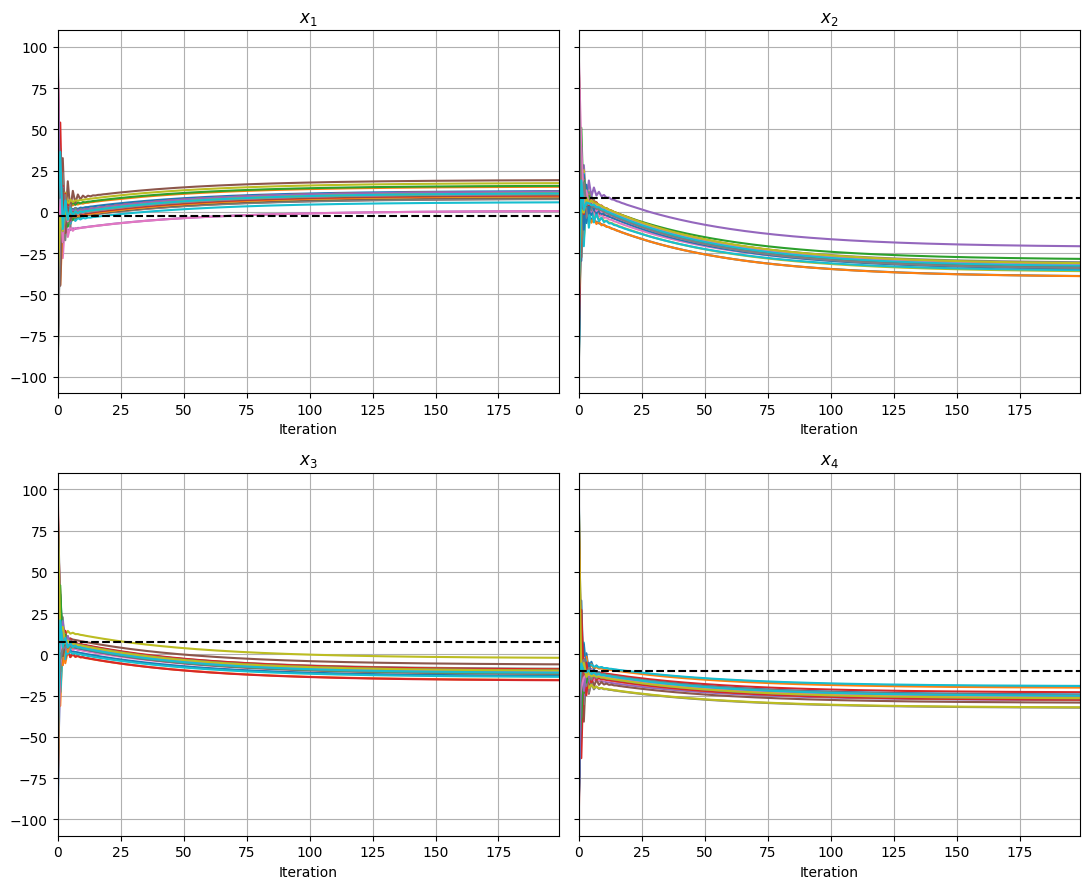

In [26]:
plt.rcdefaults()

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
axes_flat = axes.flatten()

for i in NORMAL_NODES:
    states = st_data[i]
    for j in range(N_STATE):
        ax: maxes.Axes = axes_flat[j]
        ax.plot(states[:, j])

initial_states = [st_data[i][0, :] for i in NORMAL_NODES]
mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

for j in range(N_STATE):
    ax: maxes.Axes = axes_flat[j]
    ax.axhline(mean_states[j], color="k", linestyle="--")

for j in range(N_STATE):
    ax: maxes.Axes = axes_flat[j]
    ax.set_xlabel("Iteration")
    ax.set_xlim(0, N_ITER - 1)
    ax.set_title(f"$x_{j + 1}$")
    ax.grid()

fig.tight_layout()

## (2) Reputation
### A-RepC

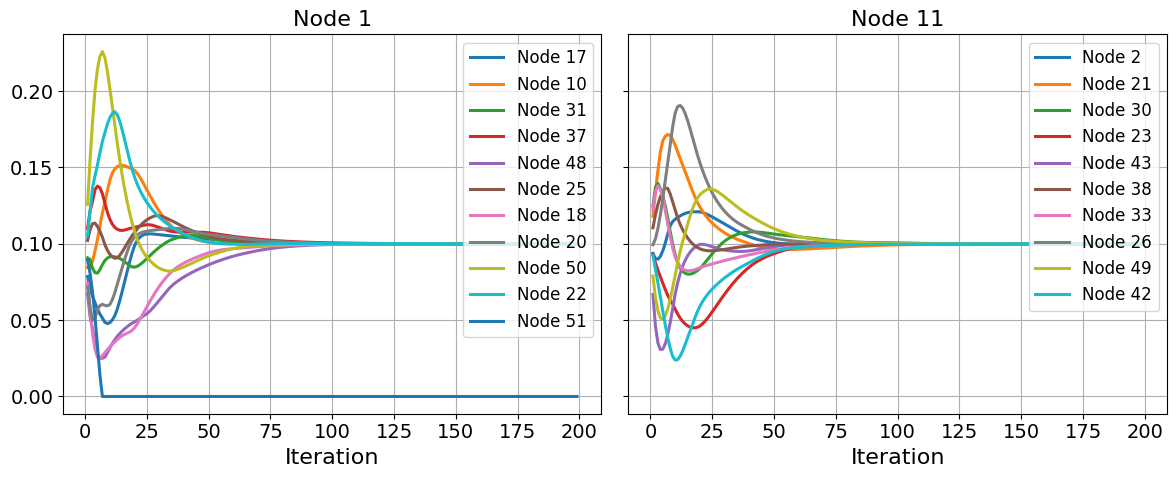

In [27]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: np.ndarray
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}
representative_nodes = ["1", "11"]

for i, ax in zip(representative_nodes, axes.flatten()):
    ax: maxes.Axes
    reps_for_i = arepc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.set_xlabel("Iteration")
    ax.legend(loc="upper right")
    ax.grid()

fig.tight_layout()

### RepC

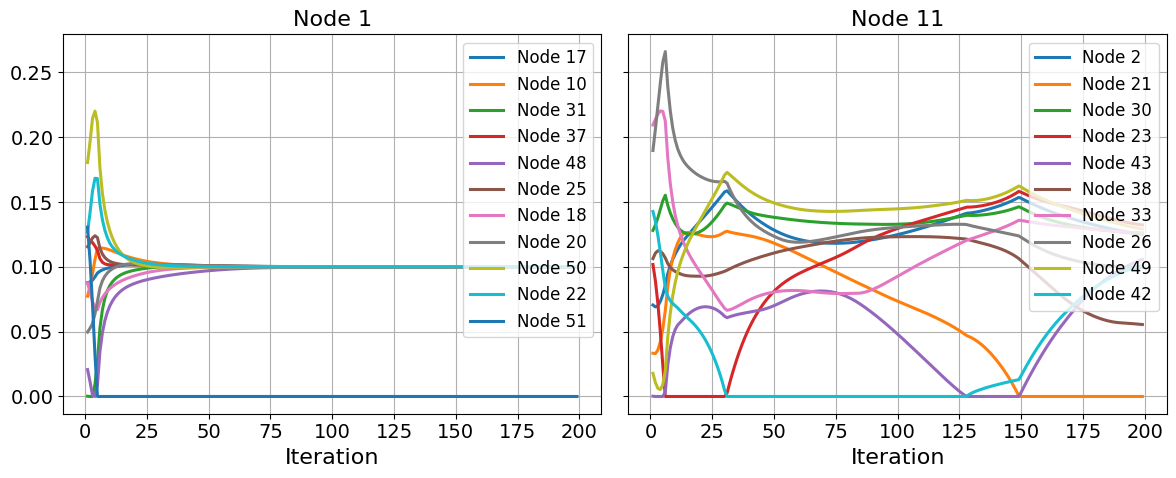

In [28]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: np.ndarray
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}
representative_nodes = ["1", "11"]

for i, ax in zip(representative_nodes, axes.flatten()):
    ax: maxes.Axes
    reps_for_i = repc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.set_xlabel("Iteration")
    ax.legend(loc="upper right")
    ax.grid()

fig.tight_layout()

### WLA

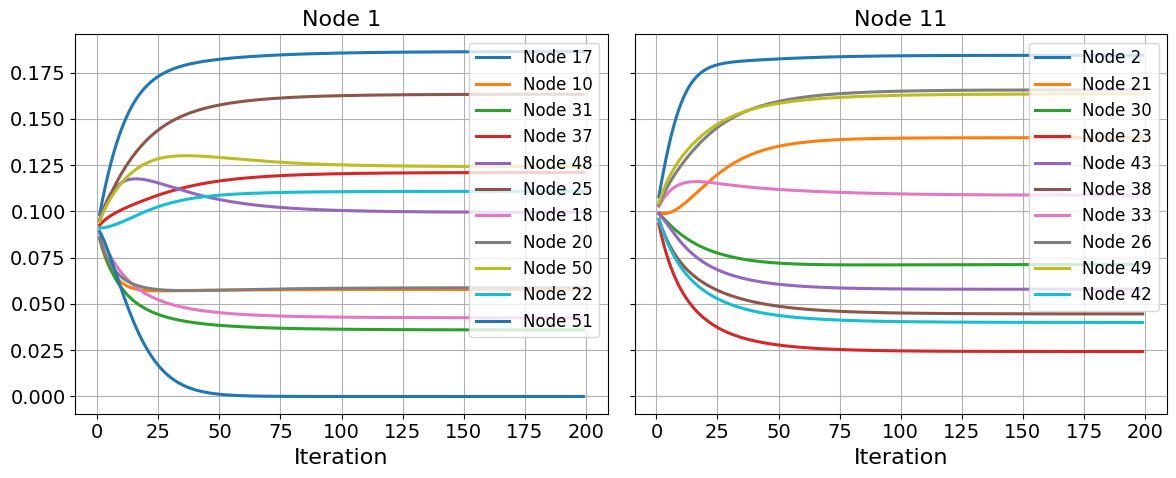

In [29]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: np.ndarray
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

wla_reps = {i: wla_data[i][1] for i in NORMAL_NODES}
representative_nodes = ["1", "11"]

for i, ax in zip(representative_nodes, axes.flatten()):
    ax: maxes.Axes
    reps_for_i = wla_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.set_xlabel("Iteration")
    ax.legend(loc="upper right")
    ax.grid()

fig.tight_layout()

## (3) Comparison

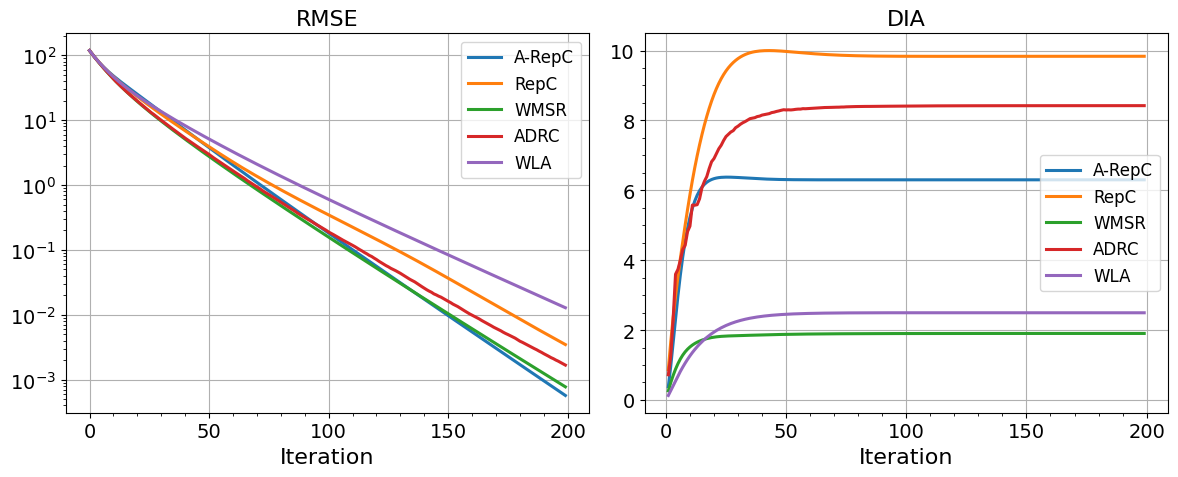

In [30]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1: maxes.Axes = axes[0]
ax2: maxes.Axes = axes[1]

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
arepc_avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - arepc_avg_states
arepc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

repc_states = np.array([repc_data[i][0] for i in NORMAL_NODES])
repc_avg_states: npt.NDArray[np.float64] = np.average(repc_states, axis=0)
diffs = repc_states - repc_avg_states
repc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

wmsr_states = np.array([wmsr_data[i] for i in NORMAL_NODES])
wmsr_avg_states: npt.NDArray[np.float64] = np.average(wmsr_states, axis=0)
diffs = wmsr_states - wmsr_avg_states
wmsr_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

adrc_states = np.array([adrc_data[i] for i in NORMAL_NODES])
adrc_avg_states: npt.NDArray[np.float64] = np.average(adrc_states, axis=0)
diffs = adrc_states - adrc_avg_states
adrc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

wla_states = np.array([wla_data[i][0] for i in NORMAL_NODES])
wla_avg_states: npt.NDArray[np.float64] = np.average(wla_states, axis=0)
diffs = wla_states - wla_avg_states
wla_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

ax1.semilogy(ITERS, arepc_rmse, label="A-RepC")
ax1.semilogy(ITERS, repc_rmse, label="RepC")
ax1.semilogy(ITERS, wmsr_rmse, label="WMSR")
ax1.semilogy(ITERS, adrc_rmse, label="ADRC")
ax1.semilogy(ITERS, wla_rmse, label="WLA")
ax1.set_xlabel("Iteration")
ax1.set_title("RMSE")
ax1.legend()
ax1.minorticks_on()
ax1.grid()

fig.tight_layout()

arepc_x0_mean = arepc_avg_states[0]
arepc_drift = np.linalg.norm(arepc_avg_states - arepc_x0_mean[None, :], axis=1)

repc_x0_mean = repc_avg_states[0]
repc_drift = np.linalg.norm(repc_avg_states - repc_x0_mean[None, :], axis=1)

wmsr_x0_mean = wmsr_avg_states[0]
wmsr_drift = np.linalg.norm(wmsr_avg_states - wmsr_x0_mean[None, :], axis=1)

adrc_x0_mean = adrc_avg_states[0]
adrc_drift = np.linalg.norm(adrc_avg_states - adrc_x0_mean[None, :], axis=1)

wla_x0_mean = wla_avg_states[0]
wla_drift = np.linalg.norm(wla_avg_states - wla_x0_mean[None, :], axis=1)

ax2.plot(ITERS[1:], arepc_drift[1:], label="A-RepC")
ax2.plot(ITERS[1:], repc_drift[1:], label="RepC")
ax2.plot(ITERS[1:], wmsr_drift[1:], label="WMSR")
ax2.plot(ITERS[1:], adrc_drift[1:], label="ADRC")
ax2.plot(ITERS[1:], wla_drift[1:], label="WLA")
ax2.set_xlabel("Iteration")
ax2.set_title("DIA")
ax2.legend()
ax2.minorticks_on()
ax2.grid()

fig.tight_layout()

# 5. Shutdown the cluster

In [18]:
ray.shutdown()